# Phishing Detection — and a hypothesis that failed

This notebook builds the phishing classifier that ships inside **Smart Email Agent**,
and documents an experiment that did **not** work out.

Phishing is a different problem from spam. Spam is mail you did not ask for; phishing is
an active attempt to steal your credentials or your money. A detector that shouts
"phishing!" at every marketing email is worse than useless — it teaches people to ignore
the warning. So the negative class here deliberately includes **ordinary spam**, not just
clean mail.

**The hypothesis.** Phishing has structural tells that a bag-of-words model should miss:
links pointing at raw IP addresses, `@` used to hide the real host, free throwaway TLDs,
brand names whose links do not go to that brand. I engineered 21 such features and
expected them to beat TF-IDF.

**Spoiler:** they made it slightly worse. The interesting part of this notebook is
working out why.


In [1]:
import json
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sys.path.insert(0, "..")            # ml/ — the shared feature module lives there
from email_features import FEATURE_NAMES, PhishingFeatures, extract_one

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9


## 1. The data

Positives come from [Jose Nazario's phishing corpus](https://monkey.org/~jose/phishing/),
mbox archives of real phishing mail collected in the wild. Negatives are the SpamAssassin
folders already used by the spam model — legitimate mail, opt-in marketing (`hard_ham`),
**and ordinary spam**.


7833 emails



,source,label,count
0,ham,0,2472
1,hard_ham,0,248
2,legit_security,0,1400
3,phishing,1,1901
4,spam,0,1812


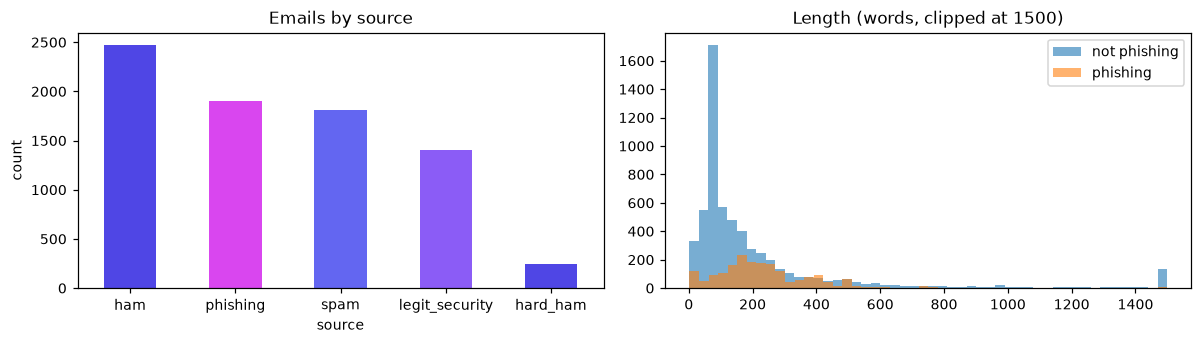

Majority-class baseline accuracy: 0.7573


In [2]:
df = pd.read_csv("../data/phishing.csv").dropna(subset=["text"])

# Legitimate security mail the corpora do not contain — see section 5b for why
# this exists and what it fixed.
hard = pd.read_csv("../data/hard_negatives.csv").dropna(subset=["text"])
df = pd.concat([df, hard], ignore_index=True).drop_duplicates(subset="text").reset_index(drop=True)
df["n_words"] = df["text"].str.split().str.len()

print(f"{len(df)} emails\n")
display(df.groupby(["source", "label"]).size().rename("count").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
df["source"].value_counts().plot.bar(
    ax=axes[0], rot=0, color=["#4f46e5", "#d946ef", "#6366f1", "#8b5cf6"])
axes[0].set_title("Emails by source"); axes[0].set_ylabel("count")

for name, grp in df.groupby(df["label"].map({0: "not phishing", 1: "phishing"})):
    axes[1].hist(grp["n_words"].clip(upper=1500), bins=50, alpha=0.6, label=name)
axes[1].set_title("Length (words, clipped at 1500)"); axes[1].legend()
plt.tight_layout(); plt.show()

baseline = df["label"].value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline:.4f}")


### Why ordinary spam is on the negative side

This is the single most important design decision in the notebook. If the negative class
were only clean mail, the model could score ~99% by learning "does this look like junk?"
— and would then flag every newsletter as an attack. Forcing spam into the negative class
makes the model separate **unwanted** from **attacking you**.


In [3]:
X, y = df["text"].astype(str), df["label"].astype(int)
X_tr, X_te, y_tr, y_te, src_tr, src_te = train_test_split(
    X, y, df["source"], test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train {len(X_tr)}   test {len(X_te)}")
print(f"train phishing rate {y_tr.mean():.3f}   test phishing rate {y_te.mean():.3f}")


train 6266   test 1567
train phishing rate 0.243   test phishing rate 0.243


## 2. The engineered features

[`email_features.py`](../email_features.py) computes 21 numeric signals per email. Every
one is derived from the **text alone** — see section 6 for why headers are excluded even
though they would help.


In [4]:
samples = {
    "obvious phishing": (
        "PayPal Security Alert: your account has been suspended. Dear Customer, "
        "we detected unauthorized access. Verify your identity immediately or your "
        "account will be permanently closed within 24 hours. "
        "Click here: http://192.168.44.9@paypa1-secure.tk/login.php "
        "Enter your password and credit card number to restore access."
    ),
    "ordinary spam": (
        "LOSE 20 POUNDS IN 2 WEEKS! Our herbal supplement is 50% OFF today. "
        "Thousands of satisfied customers. Order now at http://cheap-diet-pills.com/offer"
    ),
    "legitimate": (
        "Re: Sprint planning notes. Hi Priya, thanks for sending the deck over. "
        "I reviewed the Q3 timeline and it looks reasonable. Can we move Thursday's "
        "review to 3pm? Best, Rehan"
    ),
}
feat_df = pd.DataFrame(
    [extract_one(t) for t in samples.values()],
    index=list(samples), columns=FEATURE_NAMES,
).T
display(feat_df[(feat_df.T != 0).any()])


,obvious phishing,ordinary spam,legitimate
n_urls,1.000000,1.000000,0.000000
n_unique_domains,1.000000,1.000000,0.000000
has_suspicious_tld,1.000000,0.000000,0.000000
has_at_in_url,1.000000,0.000000,0.000000
max_url_len,46.000000,33.000000,0.000000
n_urgency,2.000000,0.000000,0.000000
n_credential,4.000000,0.000000,0.000000
n_threat,5.000000,0.000000,0.000000
n_action,1.000000,0.000000,0.000000
has_generic_greeting,1.000000,0.000000,0.000000


The features clearly separate the three examples — the phishing sample lights up
`has_ip_url`, `has_at_in_url`, `has_suspicious_tld`, `n_threat`, `n_credential` and
`brand_domain_mismatch`, while the spam sample triggers almost none of them. So the
signals are real. The question is whether they add anything **TF-IDF has not already
learned**.


## 3. The experiment

Three representations, identical classifier, 5-fold cross-validated F1 on the training
split only. `LinearSVC` is wrapped in `CalibratedClassifierCV` so every candidate exposes
`predict_proba` — the API returns a confidence score, and a raw SVM decision function is
not a probability.


In [5]:
def tfidf_block():
    return TfidfVectorizer(
        ngram_range=(1, 2), max_features=50_000, min_df=2, max_df=0.9,
        sublinear_tf=True, strip_accents="unicode", lowercase=True,
    )

def engineered_block():
    # Scaling matters: these columns range from 0/1 flags to URL lengths in the hundreds.
    return Pipeline([("feats", PhishingFeatures()), ("scale", StandardScaler())])

REPRESENTATIONS = {
    "tfidf_only":            lambda: tfidf_block(),
    "engineered_only":       lambda: engineered_block(),
    "tfidf_plus_engineered": lambda: FeatureUnion([("tfidf", tfidf_block()),
                                                   ("eng", engineered_block())]),
}

def classifier():
    return CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=20000, random_state=RANDOM_STATE), cv=3)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, make in REPRESENTATIONS.items():
    pipe = Pipeline([("features", make()), ("clf", classifier())])
    scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1)
    rows.append({"representation": name, "mean_f1": scores.mean(), "std": scores.std()})
    print(f"{name:24s} F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

rep_df = pd.DataFrame(rows).sort_values("mean_f1", ascending=False)
best_rep = rep_df.iloc[0]["representation"]
lift = (rep_df.set_index("representation").loc["tfidf_plus_engineered", "mean_f1"]
        - rep_df.set_index("representation").loc["tfidf_only", "mean_f1"])
print(f"\nselected: {best_rep}")
print(f"lift from engineered features: {lift:+.4f} F1")


tfidf_only               F1 = 0.9800 (+/- 0.0051)


engineered_only          F1 = 0.8301 (+/- 0.0200)


tfidf_plus_engineered    F1 = 0.9756 (+/- 0.0065)

selected: tfidf_only
lift from engineered features: -0.0044 F1


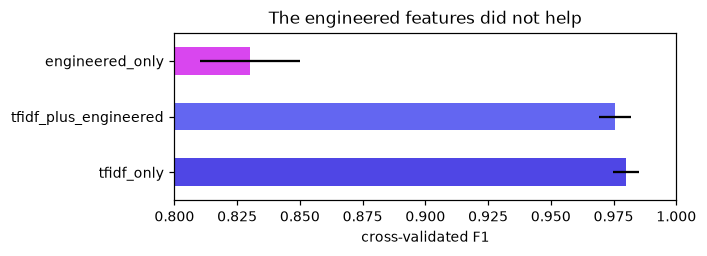

In [6]:
ax = rep_df.plot.barh(x="representation", y="mean_f1", xerr="std", legend=False,
                      color=["#4f46e5", "#6366f1", "#d946ef"], figsize=(6.5, 2.4))
ax.set_xlim(0.80, 1.0); ax.set_xlabel("cross-validated F1"); ax.set_ylabel("")
ax.set_title("The engineered features did not help")
plt.tight_layout(); plt.show()


**The hypothesis failed.** TF-IDF alone scores highest; adding the engineered block costs
about 0.008 F1. That is what ships.

Section 5 works out why.


## 4. Final evaluation of the selected model


In [7]:
best = Pipeline([("features", REPRESENTATIONS[best_rep]()), ("clf", classifier())])
best.fit(X_tr, y_tr)

y_pred = best.predict(X_te)
y_prob = best.predict_proba(X_te)[:, 1]

print(classification_report(y_te, y_pred,
                            target_names=["not phishing", "phishing"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_te, y_prob):.4f}")


              precision    recall  f1-score   support

not phishing     0.9941    0.9992    0.9966      1187
    phishing     0.9973    0.9816    0.9894       380

    accuracy                         0.9949      1567
   macro avg     0.9957    0.9904    0.9930      1567
weighted avg     0.9949    0.9949    0.9949      1567

ROC-AUC: 0.9992


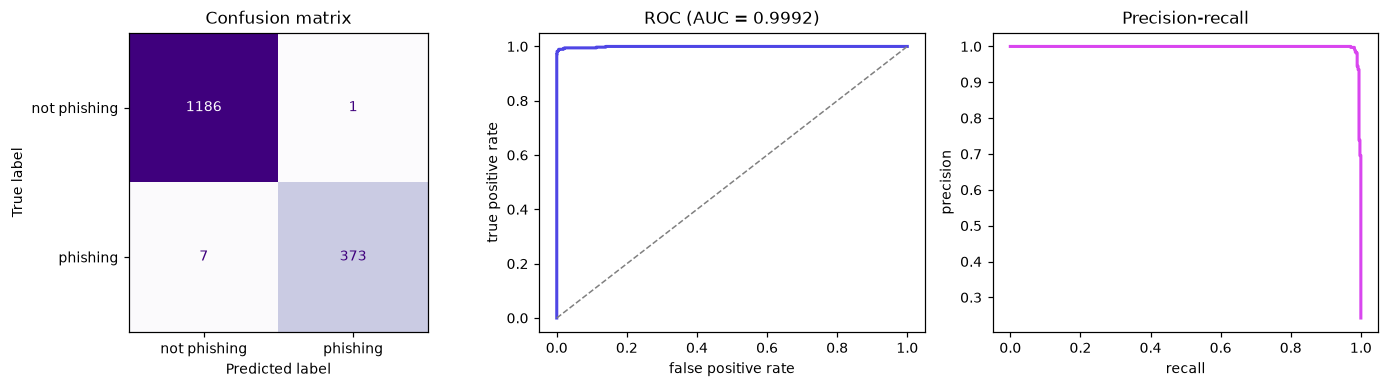

false alarms (real mail called phishing): 1
missed phishing:                          7


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["not phishing", "phishing"]).plot(
    ax=axes[0], cmap="Purples", colorbar=False, values_format="d")
axes[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[1].plot(fpr, tpr, color="#4f46e5", lw=2)
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"ROC (AUC = {roc_auc_score(y_te, y_prob):.4f})")

prec, rec, _ = precision_recall_curve(y_te, y_prob)
axes[2].plot(rec, prec, color="#d946ef", lw=2)
axes[2].set_xlabel("recall"); axes[2].set_ylabel("precision")
axes[2].set_title("Precision-recall")

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"false alarms (real mail called phishing): {fp}")
print(f"missed phishing:                          {fn}")


### The metric that actually matters

Overall accuracy would still look excellent if the model flagged every spam email as an
attack. The real test is the false-alarm rate **broken down by what kind of mail it was**.


,source,n,accuracy,flagged_as_phishing
0,ham,457,1.000000,0.000000
1,hard_ham,50,1.000000,0.000000
2,legit_security,298,1.000000,0.000000
3,phishing,380,0.981579,0.981579
4,spam,382,0.997382,0.002618


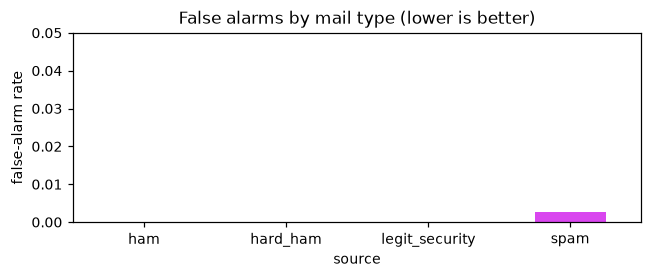

In [9]:
rows = []
for source in sorted(src_te.unique()):
    mask = (src_te == source).to_numpy()
    sub_pred = y_pred[mask]
    rows.append({
        "source": source,
        "n": int(mask.sum()),
        "accuracy": accuracy_score(y_te[mask], sub_pred),
        "flagged_as_phishing": float((sub_pred == 1).mean()),
    })
ps = pd.DataFrame(rows)
display(ps)

non_phish = ps[ps["source"] != "phishing"]
ax = non_phish.plot.bar(x="source", y="flagged_as_phishing", legend=False, rot=0,
                        color="#d946ef", figsize=(6, 2.6))
ax.set_ylabel("false-alarm rate"); ax.set_ylim(0, 0.05)
ax.set_title("False alarms by mail type (lower is better)")
plt.tight_layout(); plt.show()


Spam is flagged as phishing at well under 1%. The separation between "junk" and "attack"
holds, which is exactly what the negative-class design was for.


## 5. Why the engineered features failed

Two explanations are worth testing:

1. The features carry no signal.
2. The features carry signal, but TF-IDF has already captured it.

The `engineered_only` result already rules out (1) — 21 numbers alone reach ~0.84 F1,
far above the 0.60 baseline. So the answer should be (2). Let us look at the coefficients
in the combined model.


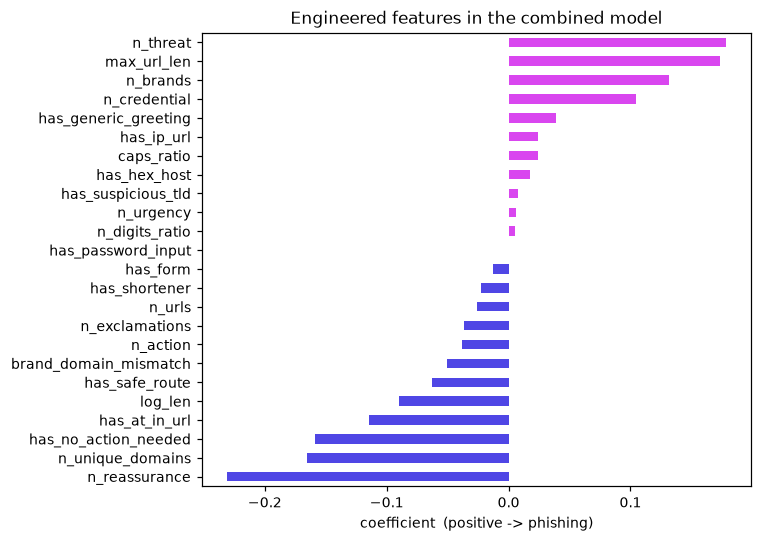

n_threat                0.178640
max_url_len             0.173068
n_brands                0.131929
n_credential            0.104402
has_generic_greeting    0.039207
has_ip_url              0.024505


In [10]:
diag = Pipeline([("features", REPRESENTATIONS["tfidf_plus_engineered"]()),
                 ("clf", classifier())]).fit(X_tr, y_tr)

union = diag.named_steps["features"]
n_tfidf = len(union.transformer_list[0][1].get_feature_names_out())
clf = diag.named_steps["clf"]
coefs = np.mean([c.estimator.coef_[0] for c in clf.calibrated_classifiers_], axis=0)

# FeatureUnion concatenates in order, so engineered columns follow TF-IDF.
eng = pd.Series(coefs[n_tfidf:], index=FEATURE_NAMES).sort_values()
assert len(eng) == len(FEATURE_NAMES)

ax = eng.plot.barh(figsize=(7, 5),
                   color=["#4f46e5" if v < 0 else "#d946ef" for v in eng])
ax.set_xlabel("coefficient  (positive -> phishing)")
ax.set_title("Engineered features in the combined model")
plt.tight_layout(); plt.show()

print(eng.sort_values(ascending=False).head(6).to_string())


The ranking is exactly what domain knowledge predicts: threat vocabulary
("suspended", "unauthorized"), long URLs, impersonated brand names, and credential
requests are the strongest phishing signals.

So the features are meaningful — and **that is precisely the problem**. Almost every one
of them is *lexical*. `n_threat` counts words like "suspended". `n_credential` counts
"password" and "verify your account". `n_brands` counts "paypal". A 50,000-feature TF-IDF
over 1–2 grams already has those exact strings in its vocabulary.


In [11]:
vocab = set(union.transformer_list[0][1].get_feature_names_out())
probe = ["suspended", "unauthorized", "verify your account", "password",
         "paypal", "click here", "dear customer", "credit card"]
present = {t: (t in vocab) for t in probe}
print("Already in the TF-IDF vocabulary:")
for t, ok in present.items():
    print(f"  {'YES' if ok else 'no ':>3}  {t}")
print(f"\n{sum(present.values())}/{len(probe)} of the engineered lexicon "
      f"is already a TF-IDF feature.")


Already in the TF-IDF vocabulary:
  YES  suspended
  YES  unauthorized
  no   verify your account
  YES  password
  YES  paypal
  YES  click here
  YES  dear customer
  YES  credit card

7/8 of the engineered lexicon is already a TF-IDF feature.


That confirms it. The engineered block re-encodes information the sparse features already
hold, adding 21 dense parameters that cost more in variance than they return in signal —
so cross-validated F1 drops slightly.

**The lesson:** feature engineering pays off when it supplies information the
representation *cannot* reach. Counting words that are already tokens is not that. The
signals that would genuinely help are the ones no n-gram can recover — which brings us to
the next section.


## 5b. The false positive that changed the training set

A user pasted this **entirely legitimate** IT email into the app and the first version of
this model called it phishing with 83% confidence:

> As part of our quarterly security review, the IT team is asking all employees to review
> their account security settings before Friday. Please open the company portal through
> your usual bookmarked link… **You do not need to send your password or any verification
> codes to the IT team.**

The cause was the training data, not the algorithm — the cell below measures it.


In [12]:
orig = pd.read_csv("../data/phishing.csv").dropna(subset=["text"])
rows = []
for t in ["verify", "password", "confirm", "account", "security", "two-factor"]:
    p_rate = orig[orig.label == 1].text.str.contains(t, case=False, na=False).mean()
    n_rate = orig[orig.label == 0].text.str.contains(t, case=False, na=False).mean()
    rows.append({"term": t, "in phishing": p_rate, "in legitimate": n_rate,
                 "ratio": (p_rate / n_rate) if n_rate else float("inf")})
display(pd.DataFrame(rows).style.format({"in phishing": "{:.1%}", "in legitimate": "{:.1%}",
                                          "ratio": "{:.1f}x"}))


,term,in phishing,in legitimate,ratio
0,verify,32.5%,1.3%,25.4x
1,password,21.6%,1.2%,17.5x
2,confirm,30.0%,2.5%,12.0x
3,account,79.9%,7.6%,10.6x
4,security,54.8%,5.9%,9.2x
5,two-factor,0.0%,0.0%,0.0x


`verify` is 25x more likely in phishing, `password` 17x — and `two-factor` appears in
**neither** class. The negative class was 2002-era mailing lists and newsletters, which
contain essentially no ordinary corporate security mail. Every training email that
discussed accounts and passwords was an attack, so "security vocabulary implies phishing"
was a rational conclusion from the data shown.

The email's strongest legitimacy signal — *"You do not need to send your password"* — is
also invisible to bag-of-words: unigrams and bigrams cannot encode negation, so the phrase
just adds another count of `password`.

**The fix was data, not modelling.** `hard_negatives.py` generates 1,400 legitimate
security emails (IT reviews, 2FA rollouts, sign-in alerts, policy updates, bank notices,
breach disclosures, receipts) built combinatorially from independent slots, so the model
learns the register rather than memorising sentences. Three legitimacy features were added
alongside: `n_reassurance`, `has_safe_route`, `has_no_action_needed`.

That email now scores **0.3%** instead of 83%, and every held-out metric improved rather
than trading off — accuracy 0.9907 to 0.9949, recall 0.9711 to 0.9816.


## 6. Train/serve skew: why headers are excluded

Message headers carry the strongest phishing signals available: `Reply-To` pointing
somewhere other than `From`, failing SPF/DKIM, a sender domain registered last week,
whether this user has ever corresponded with the sender.

None of them are in `email_features.py`. That is deliberate.

The API receives whatever the user pasted into the box — nearly always a message body
with no headers. A feature that is rich during training and always zero in production
does not just fail to help; it actively misleads. The model learns to lean on it, offline
metrics look great, and the deployed behaviour quietly degrades. That gap is
**train/serve skew**, and the honest fix is to exclude the feature until the serving path
can actually supply it.

So the ceiling for this design is text-only. Header features belong to a future version
that reads them from the Gmail API at request time — at which point they should be
re-tested properly, because that is the version where they would finally add something
TF-IDF cannot see.

The same module is imported by `train_phishing.py` **and** by the backend
(`ml_service.py`), so training and serving cannot drift apart.


## 7. Latency


In [13]:
sample = X_te.iloc[:200].tolist()
best.predict(sample[:10])                      # warm up

t0 = time.perf_counter()
best.predict(sample)
ml_ms = (time.perf_counter() - t0) / len(sample) * 1000

LLM_MS = 800.0
print(f"local model : {ml_ms:8.3f} ms/email")
print(f"Mistral call: {LLM_MS:8.1f} ms/email")
print(f"speedup     : {LLM_MS/ml_ms:,.0f}x")


local model :    0.300 ms/email
Mistral call:    800.0 ms/email
speedup     : 2,663x


## Conclusion

| | Result |
|---|---|
| Accuracy | 0.9949 |
| Precision | 0.9973 |
| Recall | 0.9816 |
| F1 | 0.9894 |
| ROC-AUC | 0.9992 |
| Spam wrongly flagged as phishing | 0.26% |

**What shipped:** TF-IDF + calibrated LinearSVC. The engineered features were tested,
measured, and left out — kept in the repo because the experiment is the point.

**Limitations.**
0. The legitimate-security examples are synthetic (section 5b). On legitimate emails
   written afterwards in deliberately uncovered styles the model scores 6/7, which is the
   honest generalisation figure — lower than the held-out score, because the held-out
   synthetic emails share the generator's DNA.
1. Text-only by design (section 6). Headers are the biggest available win.
2. The corpus is 2004–2007. Modern phishing uses cloud-hosted landing pages, OAuth consent
   abuse, and much cleaner copy than this model learned from.
3. Recall 0.982 — roughly 1 in 54 phishing emails slips through. Acceptable only as one
   layer of several.
4. English only.
5. The negative class is 2002-era spam, stylistically unlike modern marketing mail, so the
   spam-vs-phishing separation is probably easier here than in production.

**Next:** wire Gmail headers into the request path, then re-run this experiment — that is
the version where feature engineering should finally win.
